# CUSTOMER CHURN PREDICTION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymysql
import pickle

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE
from datetime import datetime 
import warnings
warnings.filterwarnings('ignore')

plt.style.use("fivethirtyeight")


In [2]:
conn = pymysql.connect(
    host="localhost",
    user="root",      
    password="MtM307@#1Wh", 
    database="customer_churn" 
)

cursor = conn.cursor()

print("Connected to MySQL successfully!")

Connected to MySQL successfully!


In [3]:
df = pd.read_sql("SELECT * FROM cleaned_data", conn)
df = df.drop(columns=['customerID'])
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df_clean = df.dropna()
print(df.shape)
df.head()


(7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [5]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

## EDA

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928,0.265370
std,0.368612,24.559481,30.090047,2265.270398,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,402.225000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.000,0.000,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.000,29.000,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.500,70.350,89.85,118.75
TotalCharges,7043.0,2281.916928,2265.270398,18.80,402.225,1397.475,3786.60,8684.80
Churn,7043.0,0.265370,0.441561,0.00,0.000,0.000,1.00,1.00


In [8]:
# Total Customers
query1 = "SELECT COUNT(*) as total_customers FROM cleaned_data"
result1 = pd.read_sql(query1, conn)
print("\n Total Customers:", result1['total_customers'].iloc[0])

# Churn Distribution
query2 = "SELECT Churn, COUNT(*) as count FROM cleaned_data GROUP BY Churn"
result2 = pd.read_sql(query2, conn)
print("\n Churn Distribution:")
print(result2)

# Average Monthly Charges by Churn
query3 = """
SELECT Churn, AVG(MonthlyCharges) as avg_charges 
FROM cleaned_data 
GROUP BY Churn
"""
result3 = pd.read_sql(query3, conn)
print("\n Average Monthly Charges by Churn:")
print(result3)

# Contract Type Distribution
query4 = "SELECT Contract, COUNT(*) as count FROM cleaned_data GROUP BY Contract"
result4 = pd.read_sql(query4, conn)
print("\n Contract Distribution:")
print(result4)

# Internet Service Distribution
query5 = "SELECT InternetService, COUNT(*) as count FROM cleaned_data GROUP BY InternetService"
result5 = pd.read_sql(query5, conn)
print("\n Internet Service Distribution:")
print(result5)

# Summary Statistics
query6 = """
SELECT 
    COUNT(*) as total_records,
    AVG(MonthlyCharges) as avg_monthly,
    AVG(TotalCharges) as avg_total,
    AVG(tenure) as avg_tenure,
    SUM(CASE WHEN Churn = 1 THEN 1 ELSE 0 END) as total_churned,
    ROUND(SUM(CASE WHEN Churn = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as churn_rate
FROM cleaned_data
"""
result6 = pd.read_sql(query6, conn)
print("\n Summary Statistics:")
print(result6)



 Total Customers: 7043

 Churn Distribution:
   Churn  count
0      0   5174
1      1   1869

 Average Monthly Charges by Churn:
   Churn  avg_charges
0      0    61.265124
1      1    74.441332

 Contract Distribution:
         Contract  count
0  Month-to-month   3875
1        One year   1473
2        Two year   1695

 Internet Service Distribution:
  InternetService  count
0             DSL   2421
1     Fiber optic   3096
2              No   1526

 Summary Statistics:
   total_records  avg_monthly    avg_total  avg_tenure  total_churned  \
0           7043    64.761692  2283.300441     32.3711         1869.0   

   churn_rate  
0       26.54  


In [9]:
def plot_distribution(df, column_name):
    plt.figure(figsize=(12 , 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[column_name], kde = True)
    plt.title(f"Distribution of {column_name}")


    col_mean = df[column_name].mean()
    col_median = df[column_name].median()
    plt.axvline(col_mean, color = "red", linestyle="--", label ="Mean")
    plt.axvline(col_median, color = "blue", linestyle="--", label ="Median")


    plt.legend()

    plt.subplot(1,2,2)
    sns.boxplot(y = df[column_name])
    plt. title(f"Boxplot of {column_name}")
    plt.show()

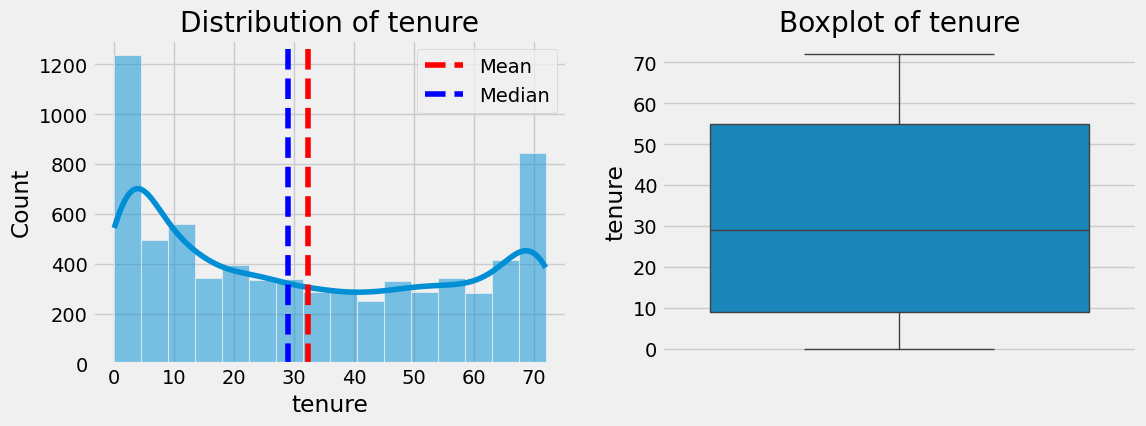

In [10]:
plot_distribution(df, "tenure")

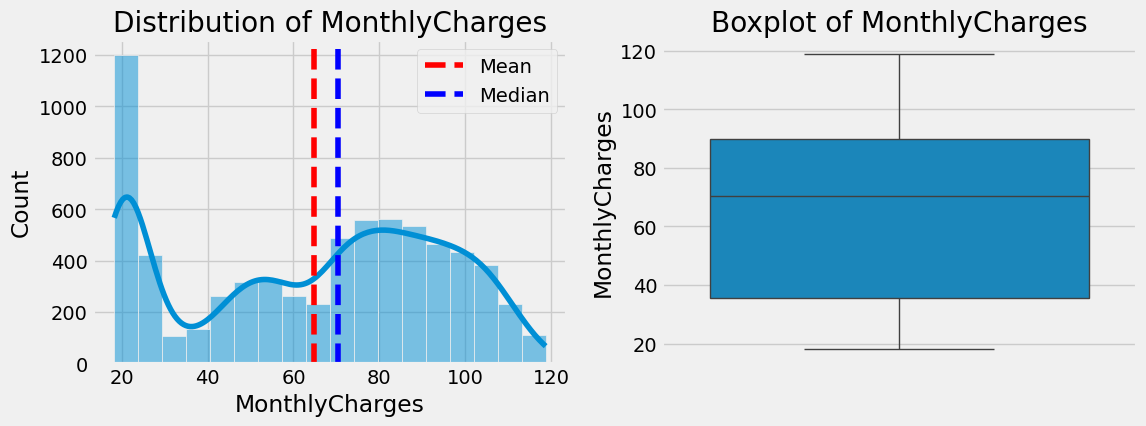

In [11]:
plot_distribution(df, "MonthlyCharges")

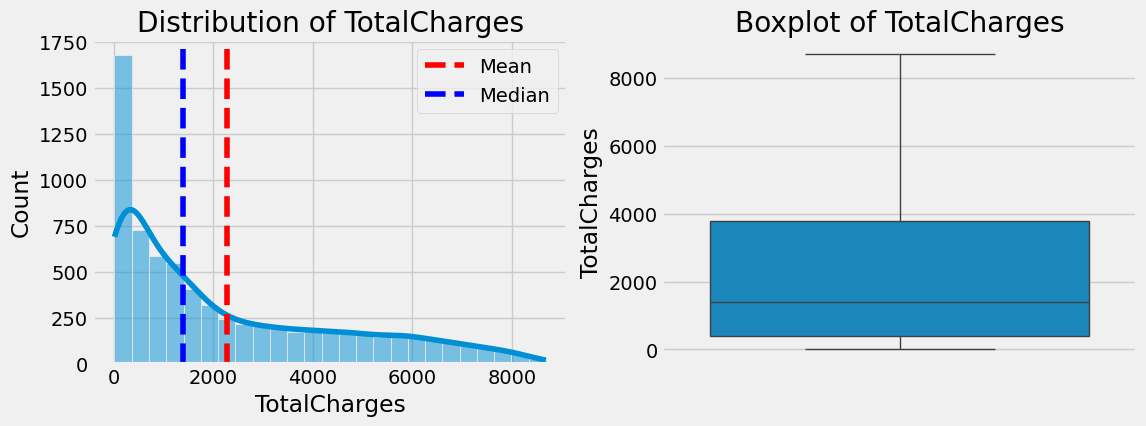

In [12]:
plot_distribution(df, "TotalCharges")

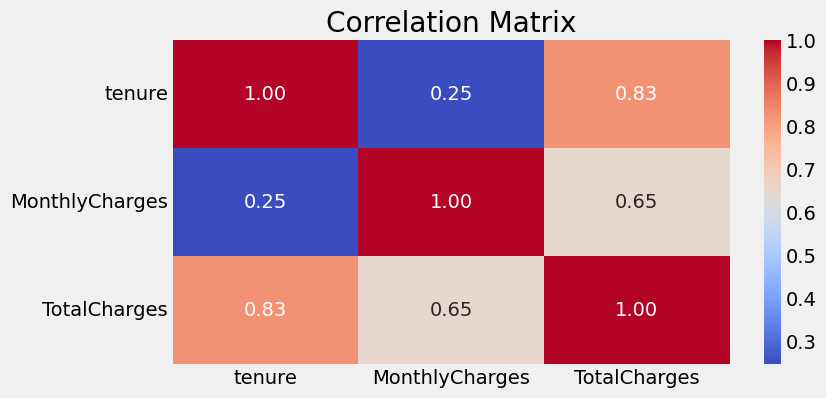

In [13]:
plt.figure(figsize = (8,4))
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True, cmap = "coolwarm", fmt = ".2f")
plt.title("Correlation Matrix")
plt.show()

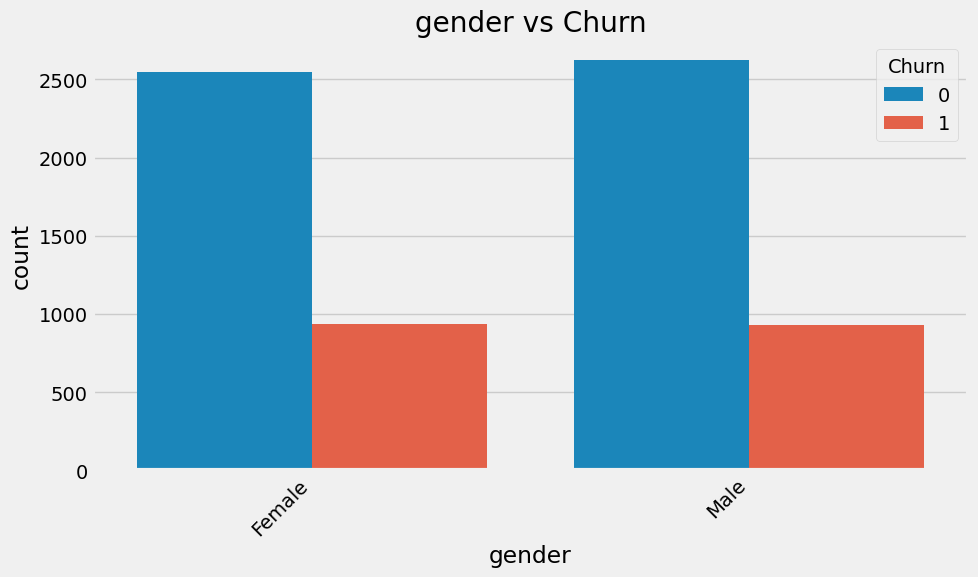

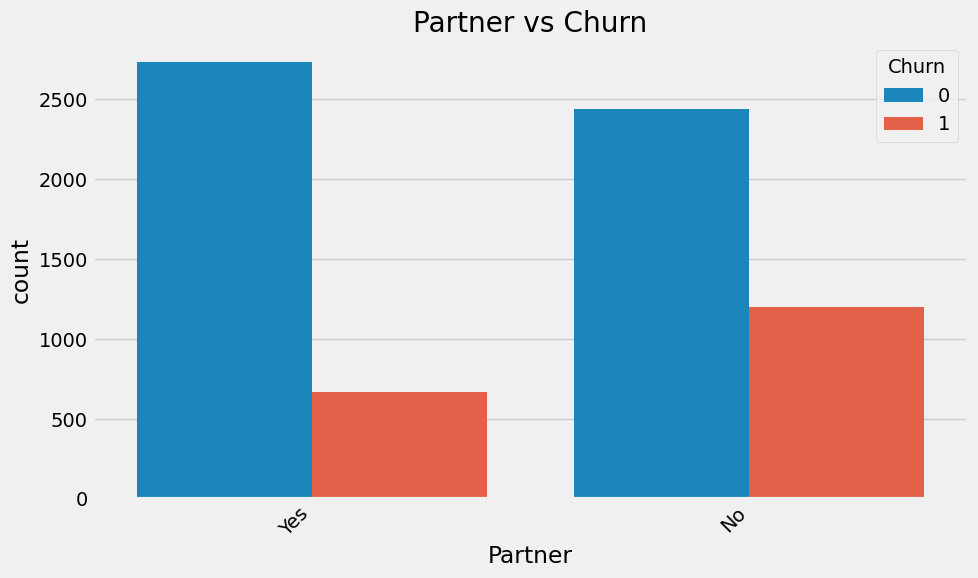

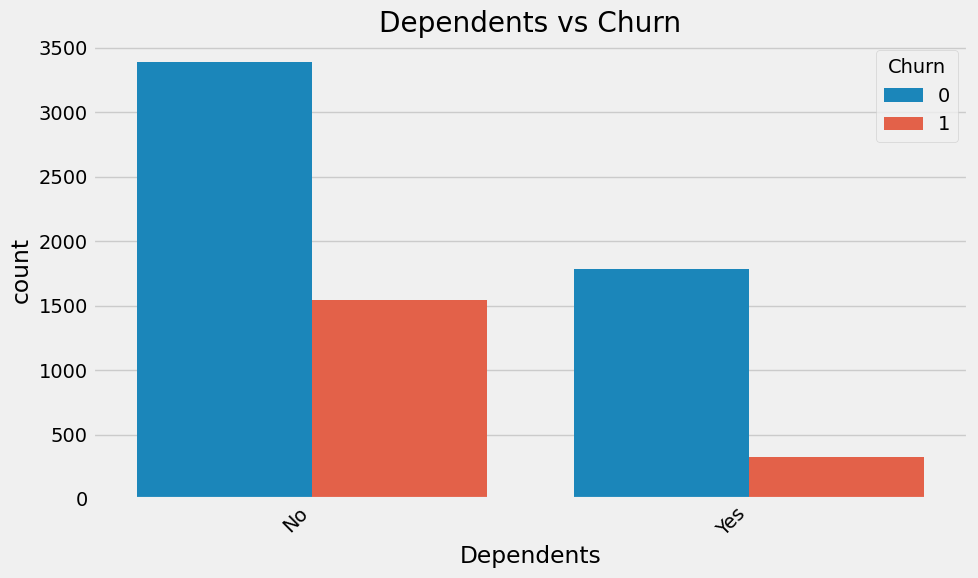

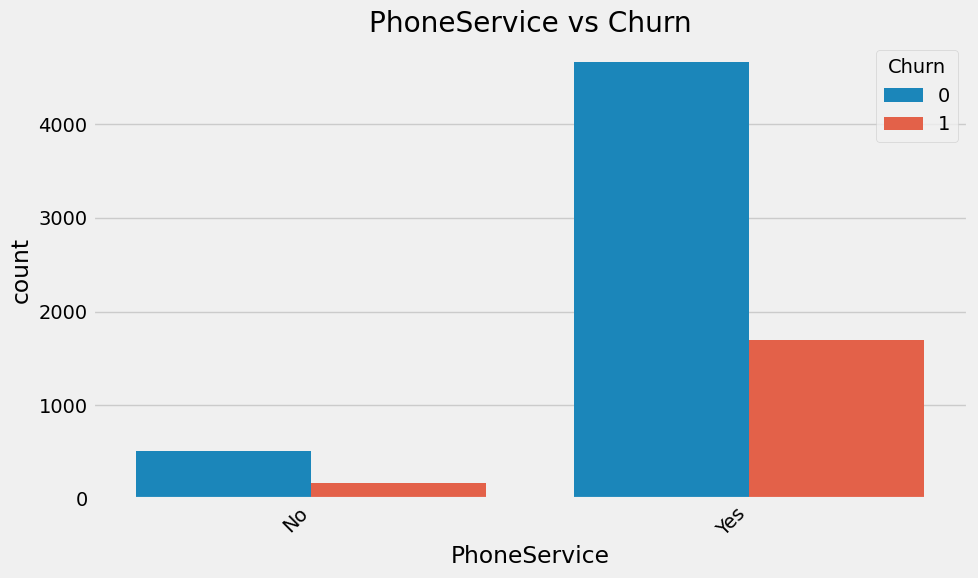

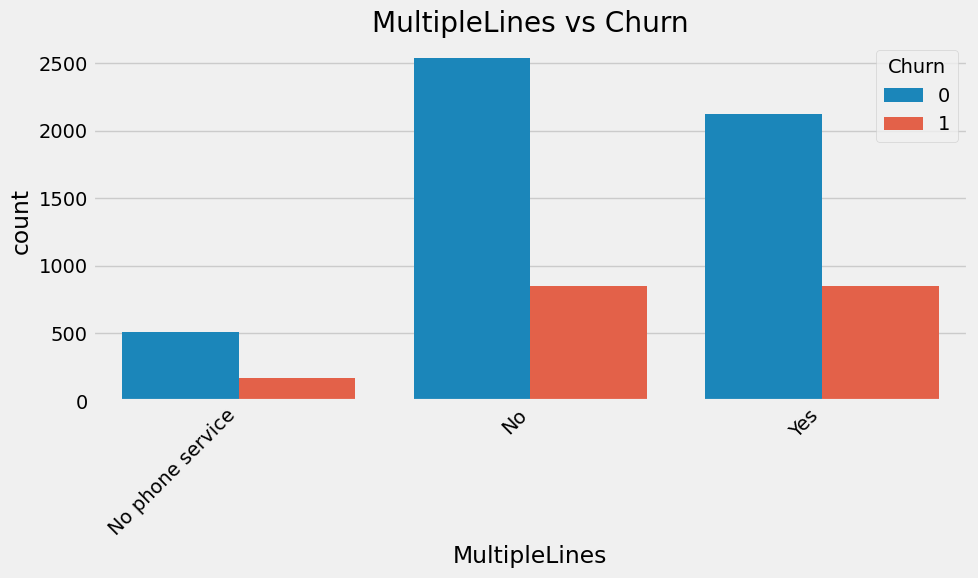

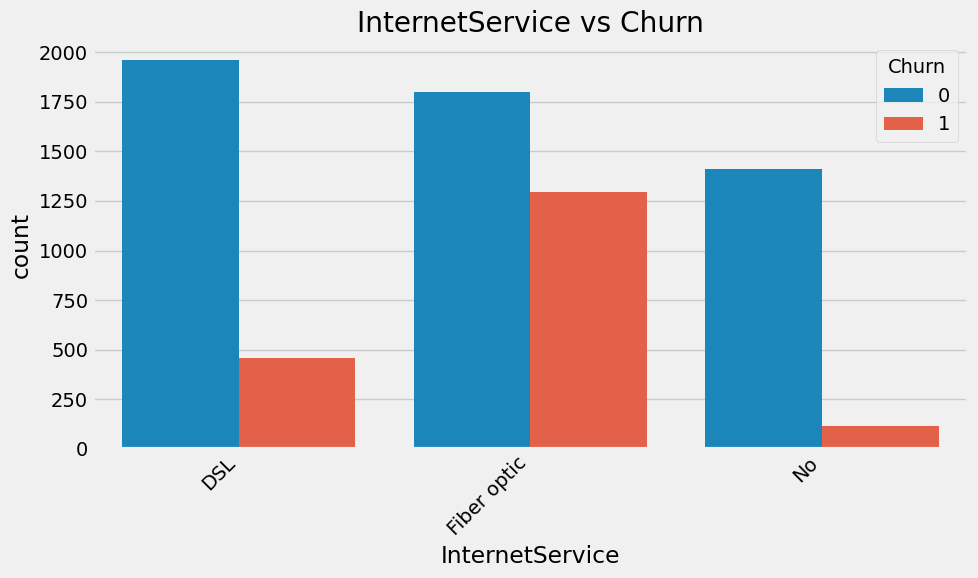

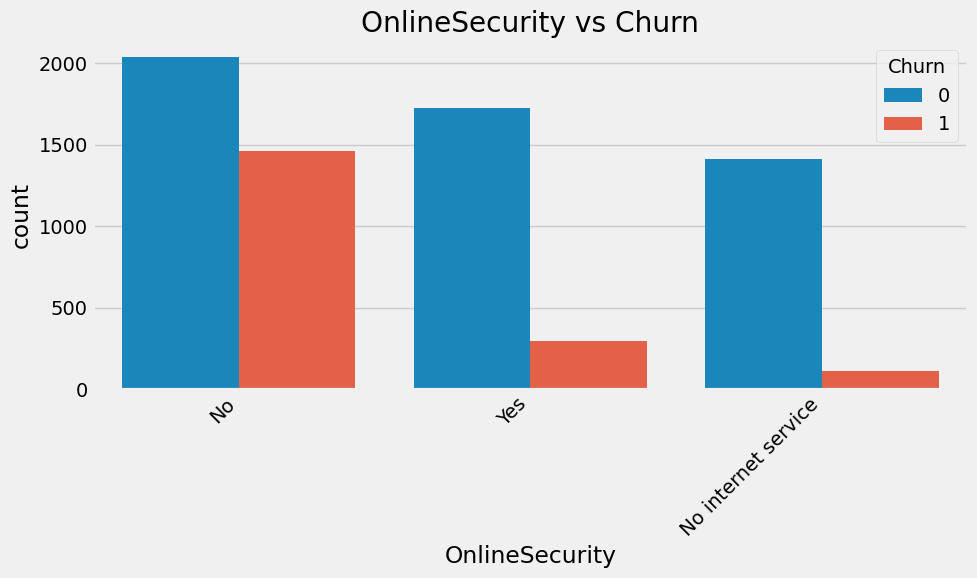

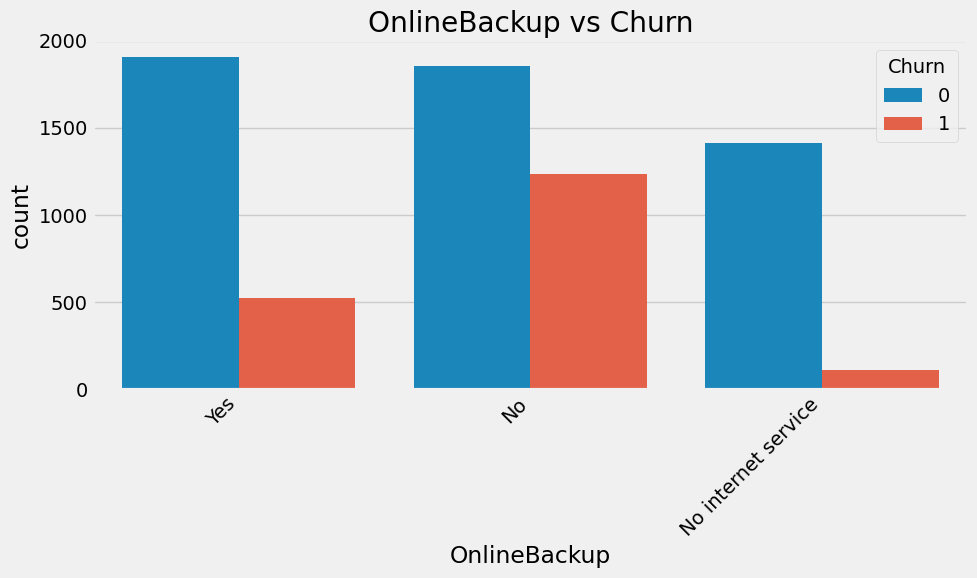

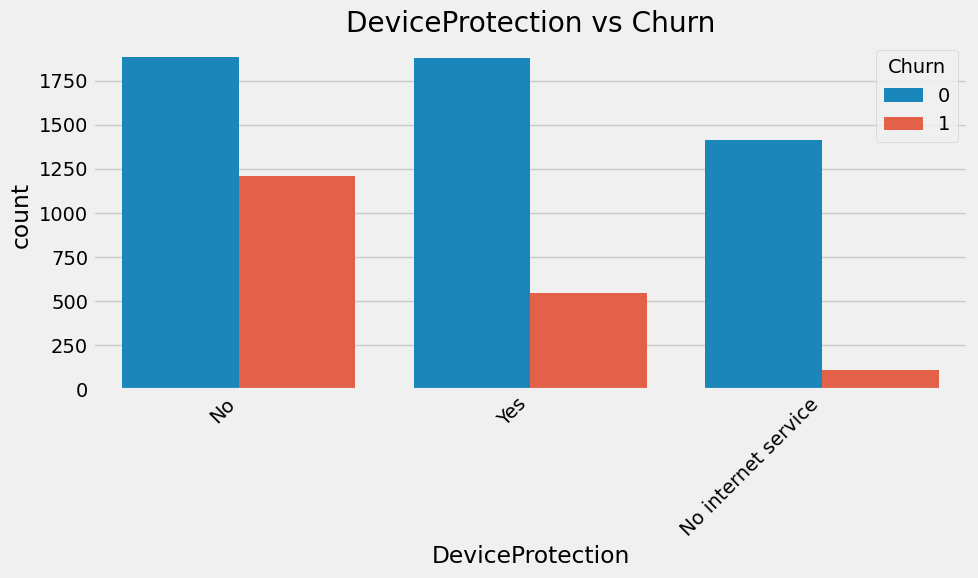

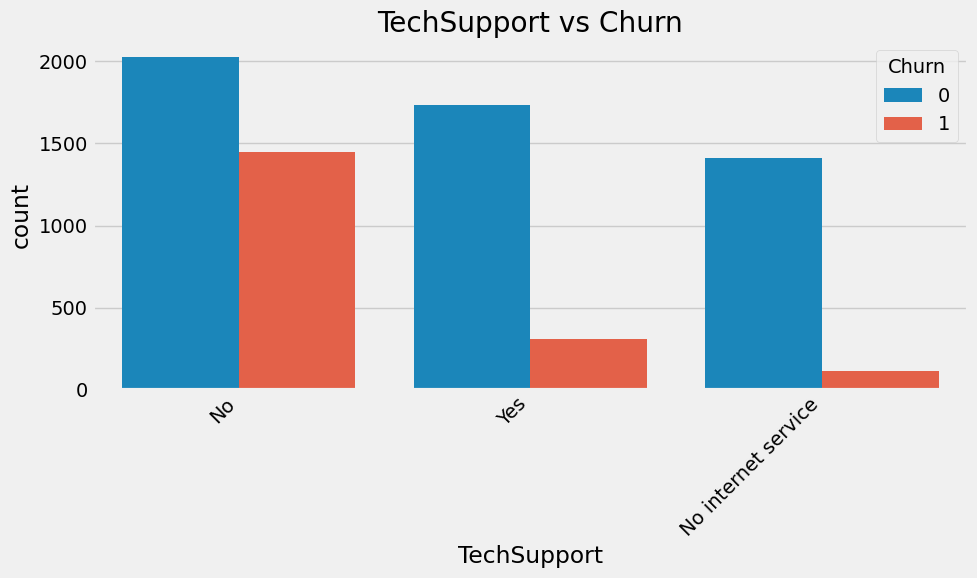

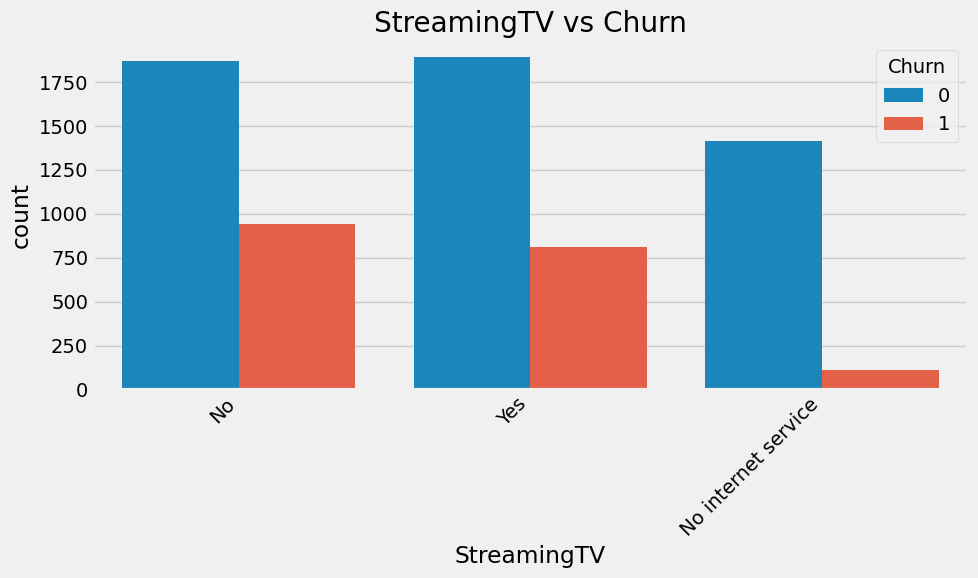

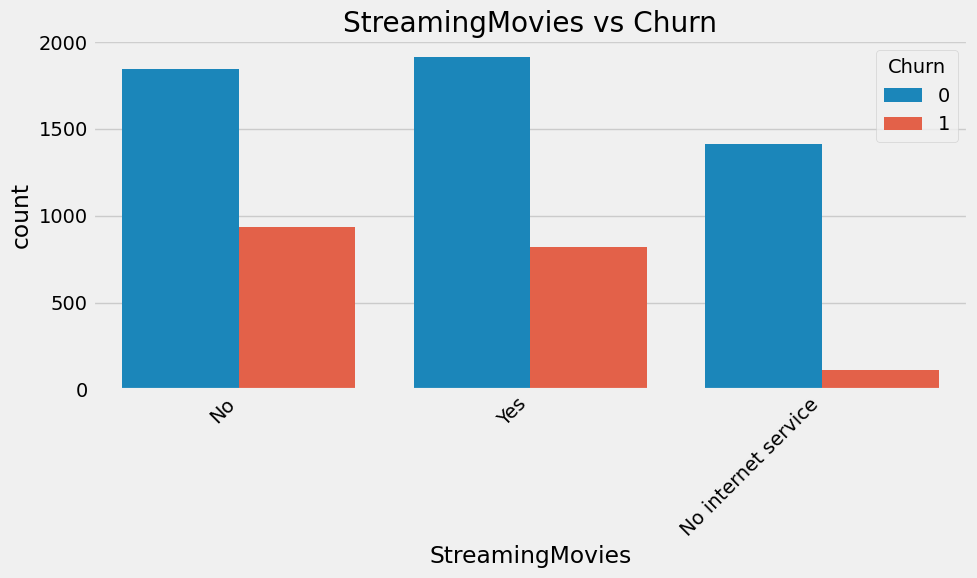

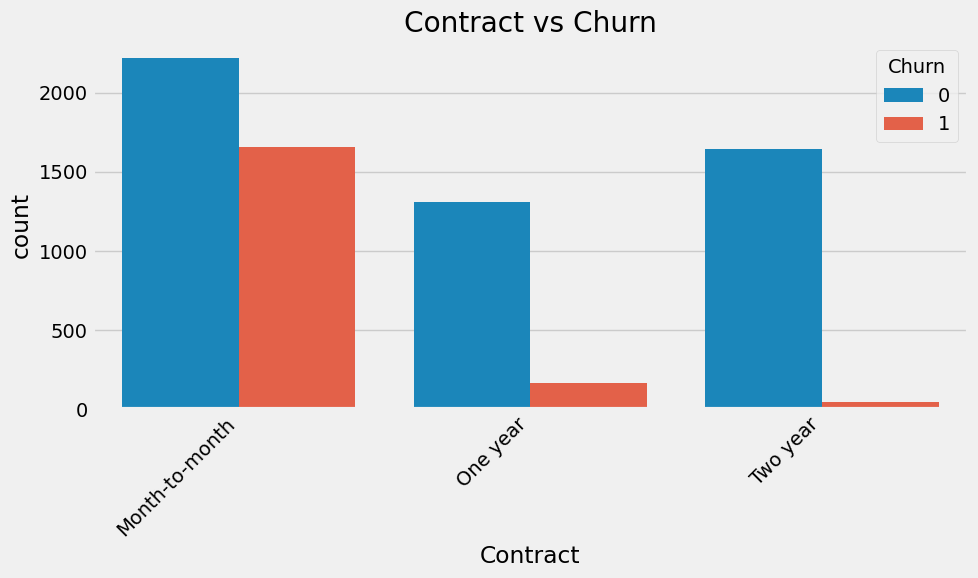

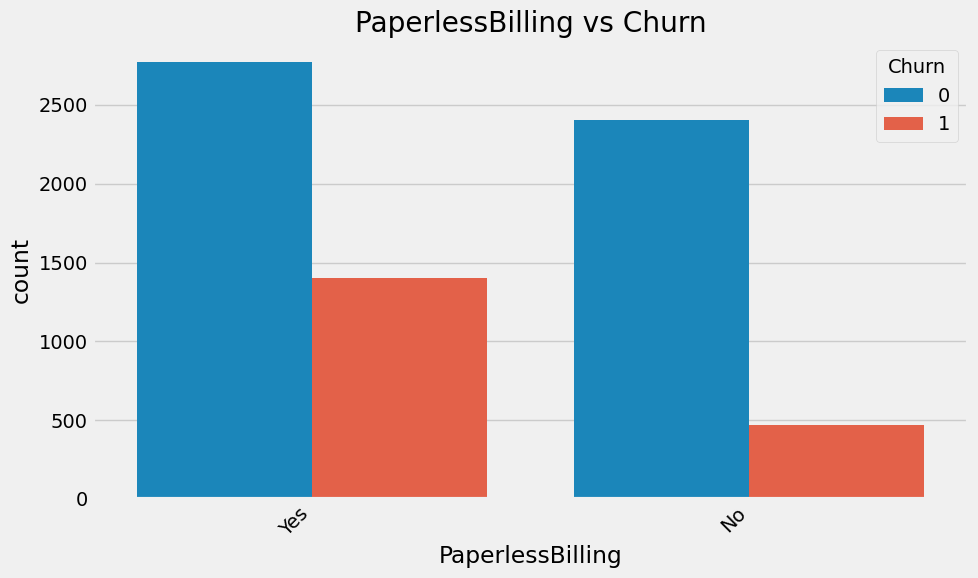

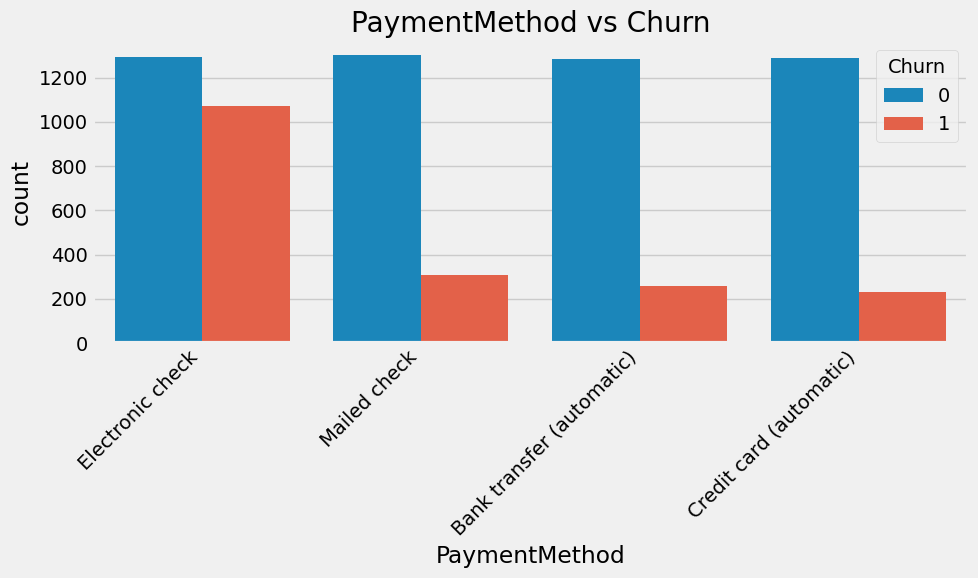

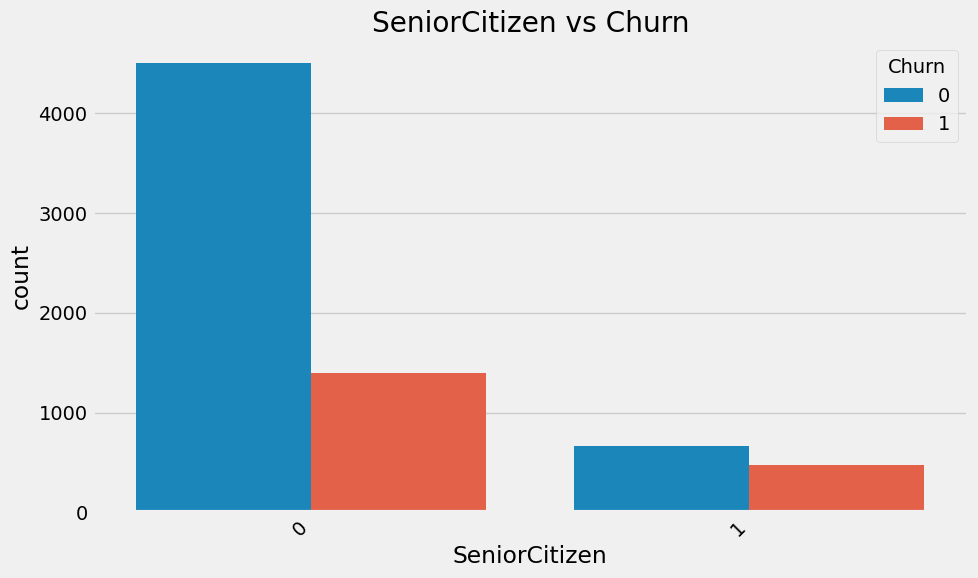

In [14]:
categorical_cols = df.select_dtypes(include="object").columns.to_list() + ['SeniorCitizen']
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col, hue='Churn') 
    plt.xticks(rotation=45, ha='right')
    plt.title(f"{col} vs Churn")
    plt.tight_layout()
    plt.show()


## Label Encoding

In [15]:
# To Encode Categorical Columns
objects_columns = df.select_dtypes(include="object").columns
encoders = {}

for column in objects_columns:
    label_encoder = LabelEncoder()
    df[column] = label_encoder.fit_transform(df[column])
    encoders[column] = label_encoder


In [16]:
with open("encoder.pkl", "wb") as f:
    pickle.dump(encoders, f)
print("Encoders Saved!")

Encoders Saved!


In [17]:
# To Scale Numerical Columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [18]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("Scaler Saved!")

# To Verify
print("\n Data Info After Encoding:")
print(df.info())

Scaler Saved!

 Data Info After Encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int32  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int32  
 3   Dependents        7043 non-null   int32  
 4   tenure            7043 non-null   float64
 5   PhoneService      7043 non-null   int32  
 6   MultipleLines     7043 non-null   int32  
 7   InternetService   7043 non-null   int32  
 8   OnlineSecurity    7043 non-null   int32  
 9   OnlineBackup      7043 non-null   int32  
 10  DeviceProtection  7043 non-null   int32  
 11  TechSupport       7043 non-null   int32  
 12  StreamingTV       7043 non-null   int32  
 13  StreamingMovies   7043 non-null   int32  
 14  Contract          7043 non-null   int32  
 15  PaperlessBilling  7043 non-null   int32  
 16  

In [19]:
X = df.drop(columns=['Churn'])
y = df['Churn']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
y_train.value_counts()

Churn
0    4138
1    1496
Name: count, dtype: int64

In [22]:
# To Handle Imbalanced Data with SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Training Data Shape:", X_train_smote.shape)
print("Test Data Shape:", X_test.shape)

Training Data Shape: (8276, 19)
Test Data Shape: (1409, 19)


In [23]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

hyperparameters = {
    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [50, 10, None]
    },
    "XGBoost": {
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 7]
    }
}

In [24]:
best_models = {}
for model_name, model in models.items():
    print(f"\n🔧 Tuning {model_name}......")
    grid = GridSearchCV(estimator=model, param_grid=hyperparameters[model_name], cv=5, scoring="accuracy")
    grid.fit(X_train_smote, y_train_smote)
    best_models[model_name] = grid.best_estimator_
    print(f"Best parameters for {model_name}: {grid.best_params_}")
    print(f"Best Accuracy for {model_name}: {grid.best_score_:.2f}")





🔧 Tuning Random Forest......
Best parameters for Random Forest: {'max_depth': 50, 'n_estimators': 200}
Best Accuracy for Random Forest: 0.84

🔧 Tuning XGBoost......
Best parameters for XGBoost: {'learning_rate': 0.2, 'max_depth': 7}
Best Accuracy for XGBoost: 0.82


In [25]:
best_models 

{'Random Forest': RandomForestClassifier(max_depth=50, n_estimators=200, random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.2, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, ...)}

In [26]:
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_models['Random Forest'], f)


In [27]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [28]:
y_test_pred = best_models['Random Forest'].predict(X_test)
y_test_prob = best_models['Random Forest'].predict_proba(X_test)[:, 1]


In [29]:
y_test_pred

array([1, 0, 0, ..., 0, 0, 0], dtype=int64)

In [30]:
y_test_prob

array([0.91 , 0.39 , 0.01 , ..., 0.015, 0.04 , 0.36 ])

In [31]:
# To Calculate Metrics
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
roc_auc = roc_auc_score(y_test, y_test_pred)

print(f"\n Model Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")


 Model Performance:
Accuracy: 0.7821
Precision: 0.5771
Recall: 0.6622
F1 Score: 0.6167
ROC-AUC: 0.7437


In [32]:
# To Insert Metrics to MySQL
current_date = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
insert_sql = """
INSERT INTO model_metrics (model_name, accuracy, precision_score, recall, f1_score, roc_auc, run_date)
VALUES (%s, %s, %s, %s, %s, %s, %s)
"""
cursor.execute(insert_sql, ('Random Forest', accuracy, precision, recall, f1, roc_auc, current_date))
conn.commit()

print("\n Metrics Saved to MySQL!")


 Metrics Saved to MySQL!


In [33]:
cursor.execute("SELECT * FROM model_metrics")
metrics = cursor.fetchall()
print("\n Saved Metrics:")
print(pd.DataFrame(metrics, columns=['id', 'model_name', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'run_date']))


 Saved Metrics:
   id     model_name accuracy precision  recall f1_score roc_auc  \
0   1  Random Forest   0.7771    0.7500  0.7200   0.7350  0.7429   
1   2  Random Forest   0.7771    0.7500  0.7200   0.7350  0.7429   
2   3        XGBoost   0.7600    0.7400  0.7100   0.7250  0.7300   
3   4  Random Forest   0.7821    0.5771  0.6622   0.6167  0.7437   
4   5  Random Forest   0.7821    0.5771  0.6622   0.6167  0.7437   
5   6  Random Forest   0.7821    0.5771  0.6622   0.6167  0.7437   
6   7  Random Forest   0.7821    0.5771  0.6622   0.6167  0.7437   
7   8  Random Forest   0.7821    0.5771  0.6622   0.6167  0.7437   
8   9  Random Forest   0.7821    0.5771  0.6622   0.6167  0.7437   

             run_date  
0 2026-03-06 11:43:59  
1 2026-03-06 11:44:40  
2 2026-03-06 11:44:40  
3 2026-03-16 16:09:48  
4 2026-03-16 21:22:17  
5 2026-03-17 16:35:32  
6 2026-03-17 17:10:27  
7 2026-03-17 17:11:47  
8 2026-03-18 15:15:56  


In [34]:
# To Load Saved Models
with open("best_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)
with open("encoder.pkl", "rb") as f:
    encoders = pickle.load(f)
with open("scaler.pkl", "rb") as f:
    scaler_data = pickle.load(f)

In [35]:
def make_prediction(input_data):
    input_df = pd.DataFrame([input_data])
    
    # Encode categorical features
    for col, encoder in encoders.items():
        input_df[col] = encoder.transform(input_df[col])
    
    # Scale numerical features
    numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
    input_df[numerical_cols] = scaler_data.transform(input_df[numerical_cols])
    
    # Make prediction
    prediction = loaded_model.predict(input_df)[0]
    probability = loaded_model.predict_proba(input_df)[0, 1]
    
    return "Churn" if prediction == 1 else "No Churn", probability

In [36]:
example_input = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 1,
    'PhoneService': 'No',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 29.85,
    'TotalCharges': 29.85
}

prediction, prob = make_prediction(example_input)
print(f"\n Prediction: {prediction}")
print(f" Probability: {prob:.2%}")


 Prediction: No Churn
 Probability: 26.00%


In [37]:
customer_id = f"CUSTOMER_{int(datetime.now().timestamp())}"
cursor.execute("""
INSERT INTO customer_predictions (customerID, actual_churn, predicted_churn, churn_probability, model_name)
VALUES (%s, %s, %s, %s, %s)
""", (customer_id, 0, 1 if prediction == "Churn" else 0, float(prob), 'Random Forest'))

conn.commit()